# Method development: Random Forest Regression
https://www.geeksforgeeks.org/machine-learning/random-forest-regression-in-python/

In [20]:
import pandas as pd
import numpy as np
import matplotlib as plt
import warnings

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

warnings.filterwarnings('ignore')

In [21]:
# Importing clean dataset
df_listings = pd.read_parquet('../data/clean_listings.parquet', engine='auto')

In [22]:
non_null_count_listings = df_listings.notnull().sum().values
nulls = df_listings.isna().sum()
types = df_listings.dtypes.values

info_df = pd.DataFrame({
    'Non-Null Count': non_null_count_listings,
    'Null Count': nulls,
    'Dtypes': types
})
print(info_df)

                         Non-Null Count  Null Count   Dtypes
listing_id                        68683          16    Int64
listing_type                      68699           0      str
room_type                         68699           0      str
cover_photo_url                   68699           0      str
photos_count                      68699           0    Int64
host_id                           68699           0      str
superhost                         68699           0  boolean
guests                            68699           0    Int64
bedrooms                          68699           0    Int64
beds                              68699           0  float64
baths                             68699           0  float64
registration                      68474         225  boolean
amenities                         68699           0      str
amenities_count                   68699           0    int64
instant_book                      14283       54416  boolean
professional_management 

In [23]:
# Selecting cols
cols = [
    'room_type', 'photos_count', 'superhost', 'guests', 'bedrooms', 'beds', 'baths', 
    'amenities_count', 'cleaning_fee', 'num_reviews', 'rating_overall', 'ttm_revenue',
    'country', 'city'
]

df_listings_cols = df_listings[cols].copy()

In [24]:
# Splitting columns
categorical_cols = df_listings_cols.select_dtypes(include=["object"]).columns.to_list()
numerical_cols = [col for col in df_listings_cols if col not in categorical_cols]

print(df_listings_cols.isna().sum())
print(len(df_listings_cols))
# Not the best approach, but simple solution for testing
df_listings_cols = df_listings_cols.dropna()
print(len(df_listings_cols))

room_type             0
photos_count          0
superhost             0
guests                0
bedrooms              0
beds                  0
baths                 0
amenities_count       0
cleaning_fee       1262
num_reviews           0
rating_overall        0
ttm_revenue           0
country               0
city                  0
dtype: int64
68699
67437


In [33]:
# Extracting features
feature_cols = [c for c in cols if c != 'ttm_revenue']
X = df_listings_cols[feature_cols]
print(X)

# Extracting target variable
y = df_listings_cols['ttm_revenue'].values
print(y)

         room_type  photos_count  superhost  guests  bedrooms  beds  baths  \
0      entire_home            77      False       6         3   4.0    1.0   
2      entire_home            34      False       5         2   4.0    1.0   
3      entire_home            70      False      16        12  15.0    6.0   
5      entire_home            42       True       6         2   3.0    1.5   
6      entire_home            55       True       6         3   3.0    2.0   
...            ...           ...        ...     ...       ...   ...    ...   
95891  entire_home            23       True       5         2   4.0    1.0   
95893  entire_home            33      False       6         2   4.0    2.0   
95894  entire_home            10      False       2         1   1.0    1.0   
95895  entire_home            13      False       5         3   5.0    2.0   
95896  entire_home            15      False       6         3   5.0    2.0   

       amenities_count  cleaning_fee  num_reviews  rating_overa

In [34]:
# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)
print(X)

         room_type  photos_count  superhost  guests  bedrooms  beds  baths  \
0      entire_home            77      False       6         3   4.0    1.0   
2      entire_home            34      False       5         2   4.0    1.0   
3      entire_home            70      False      16        12  15.0    6.0   
5      entire_home            42       True       6         2   3.0    1.5   
6      entire_home            55       True       6         3   3.0    2.0   
...            ...           ...        ...     ...       ...   ...    ...   
95891  entire_home            23       True       5         2   4.0    1.0   
95893  entire_home            33      False       6         2   4.0    2.0   
95894  entire_home            10      False       2         1   1.0    1.0   
95895  entire_home            13      False       5         3   5.0    2.0   
95896  entire_home            15      False       6         3   5.0    2.0   

       amenities_count  cleaning_fee  num_reviews  rating_overa

In [35]:
# Build preprocessor with One Hot Encoder
cat_features = [c for c in feature_cols if c in categorical_cols]
num_features = [c for c in feature_cols if c not in categorical_cols]

preprocessor = ColumnTransformer(transformers=[
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features),
    ('num', 'passthrough', num_features)
])

In [36]:
# Build pipeline with model
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42, oob_score=True))
])

pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('ohe', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [37]:
# Making predictions and evaluating

# Estimates the model's generalization performance
print("Out-of-Bag Score:", pipeline['model'].oob_score_)

# Predictions are made on the test set
y_pred = pipeline.predict(X_test)

# Evaluates the model's performance using the Mean Squared Error (MSE) metric
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)
rmse = np.sqrt(mse)
print(f"RMSE: {rmse:.2f}")  # same unit as ttm_revenue (likely $)

# Also useful: compare error relative to the target's scale
print(f"Mean of y_test: {y_test.mean():.2f}")
print(f"RMSE as % of mean: {(rmse / y_test.mean()) * 100:.2f}%")

# Evaluates the model's performance using the R-squared (R2) metric
r2 = r2_score(y_test, y_pred)
print("R-squared:", r2)

Out-of-Bag Score: 0.5196646842254089
Mean Squared Error: 271168197.616916
RMSE: 16467.19
Mean of y_test: 20864.79
RMSE as % of mean: 78.92%
R-squared: 0.5165092728430586


In [38]:
# Feature importances — reconstruct names after OHE expansion
ohe_feature_names = pipeline['preprocessor'] \
    .named_transformers_['ohe'] \
    .get_feature_names_out(cat_features).tolist()
all_feature_names = ohe_feature_names + num_features

importances = pd.Series(
    pipeline['model'].feature_importances_,
    index=all_feature_names
).sort_values(ascending=False)

print(importances.head(15))

num_reviews                 0.163506
cleaning_fee                0.127343
baths                       0.120918
bedrooms                    0.111845
rating_overall              0.053492
amenities_count             0.044003
photos_count                0.040465
guests                      0.023509
beds                        0.020374
superhost                   0.019830
city_City of Edinburgh      0.013299
city_Funchal                0.010388
city_City of Westminster    0.009933
country_United Kingdom      0.008619
city_Palma                  0.006346
dtype: float64


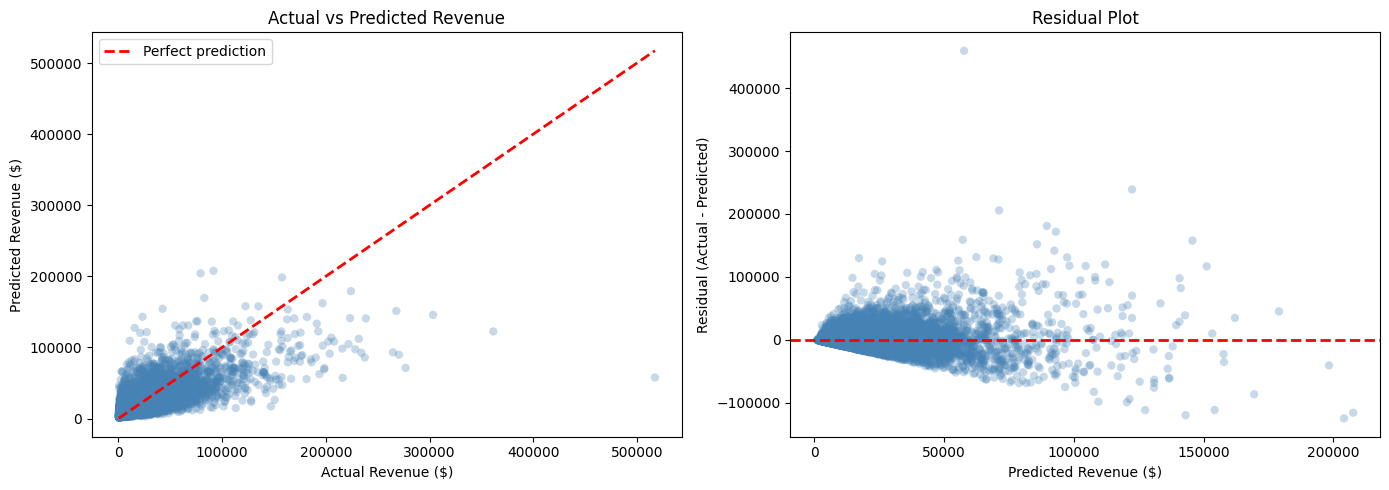

In [40]:
import matplotlib.pyplot as plt
import numpy as np

y_pred = pipeline.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Actual vs Predicted ---
axes[0].scatter(y_test, y_pred, alpha=0.3, color='steelblue', edgecolors='none')
# Perfect prediction line
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect prediction')
axes[0].set_xlabel('Actual Revenue ($)')
axes[0].set_ylabel('Predicted Revenue ($)')
axes[0].set_title('Actual vs Predicted Revenue')
axes[0].legend()

# --- Plot 2: Residuals ---
residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.3, color='steelblue', edgecolors='none')
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Predicted Revenue ($)')
axes[1].set_ylabel('Residual (Actual - Predicted)')
axes[1].set_title('Residual Plot')

plt.tight_layout()
plt.show()